# Cybersecurity Intrusion Analysis - Revised Notebook

## Section 1 - Import libraries and set display options

In this section we load the Python packages needed for data handling, charts, missing-value analysis, and machine learning.

In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## Section 2 - Load the dataset

This section reads the dataset into Python.  
Update `DATA_PATH` if your CSV file is stored in a different folder.

In [25]:
from pathlib import Path

# Change this path only if your dataset is stored somewhere else
DATA_PATH = Path(r'F:\work\Tanish\cybersecurity_intrusion_data.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Please place the CSV file in the same folder as this notebook, "
        "or update DATA_PATH to the correct location."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded successfully: 9537 rows x 11 columns


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## Section 3 - Quick structure check

Here we check the column names, data types, and whether the file has any obvious problems.

In [26]:
print("Column names:")
print(df.columns.tolist())
print("Data types and missing values:")
df.info()

Column names:
['session_id', 'network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access', 'attack_detected']
Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-nul

## Section 4 - Basic cleaning

This section performs small but important cleaning steps:
- removes identifier columns that do not help prediction
- keeps the target column in a machine-learning-friendly format
- also creates a readable copy of the target for charts

In [27]:
df = df.copy()

TARGET_COL = "attack_detected"
ID_COLS_TO_DROP = ["session_id"]

for col in ID_COLS_TO_DROP:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' was not found in the dataset.")

# Keep target numeric for modelling
if df[TARGET_COL].dtype == "object":
    unique_target = sorted(df[TARGET_COL].dropna().unique().tolist())
    if set(unique_target) <= {0, 1, "0", "1", "No", "Yes", "False", "True"}:
        df[TARGET_COL] = (
            df[TARGET_COL]
            .replace({"0": 0, "1": 1, "No": 0, "Yes": 1, "False": 0, "True": 1})
            .astype(int)
        )

# Human-readable labels for charts only
if pd.api.types.is_numeric_dtype(df[TARGET_COL]):
    df["attack_label"] = df[TARGET_COL].map({0: "No Attack", 1: "Attack"}).fillna(df[TARGET_COL].astype(str))
else:
    df["attack_label"] = df[TARGET_COL].astype(str)

print("Data after basic cleaning:")
df.info()

Data after basic cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  9537 non-null   int64  
 1   protocol_type        9537 non-null   object 
 2   login_attempts       9537 non-null   int64  
 3   session_duration     9537 non-null   float64
 4   encryption_used      7571 non-null   object 
 5   ip_reputation_score  9537 non-null   float64
 6   failed_logins        9537 non-null   int64  
 7   browser_type         9537 non-null   object 
 8   unusual_time_access  9537 non-null   int64  
 9   attack_detected      9537 non-null   int64  
 10  attack_label         9537 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


## Section 5 - Separate numeric and categorical columns

Before analysis, we split the columns into numeric and categorical groups.  
This helps us use the right summary methods and the right charts.

In [28]:
feature_df = df.drop(columns=["attack_label"], errors="ignore")

numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = feature_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Remove target from feature lists where needed
numeric_feature_cols = [col for col in numeric_cols if col != TARGET_COL]
categorical_feature_cols = [col for col in categorical_cols if col != TARGET_COL]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected']
Categorical columns: ['protocol_type', 'encryption_used', 'browser_type']


## Section 6 - Descriptive statistics

This section gives a numerical summary of the data.  
It helps us understand the average values, spread, minimums, maximums, and common categories.

In [29]:
num_stats = df[numeric_cols].describe().T if numeric_cols else pd.DataFrame()
cat_stats = df[categorical_cols + (["attack_label"] if "attack_label" in df.columns and "attack_label" not in categorical_cols else [])].describe().T

print("Numeric summary:")
display(num_stats)

print("Categorical summary:")
display(cat_stats)

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
network_packet_size,9537.0,500.430639,198.379364,64.000000,365.000000,499.000000,635.000000,1285.000000
login_attempts,9537.0,4.032086,1.963012,1.000000,3.000000,4.000000,5.000000,13.000000
session_duration,9537.0,792.745312,786.560144,0.500000,231.953006,556.277457,1105.380602,7190.392213
ip_reputation_score,9537.0,0.331338,0.177175,0.002497,0.191946,0.314778,0.453388,0.924299
failed_logins,9537.0,1.517773,1.033988,0.000000,1.000000,1.000000,2.000000,5.000000
unusual_time_access,9537.0,0.149942,0.357034,0.000000,0.000000,0.000000,0.000000,1.000000
attack_detected,9537.0,0.447101,0.497220,0.000000,0.000000,0.000000,1.000000,1.000000


Categorical summary:


,count,unique,top,freq
protocol_type,9537,3,TCP,6624
encryption_used,7571,2,AES,4706
browser_type,9537,5,Chrome,5137
attack_label,9537,2,No Attack,5273


## Section 7 - Missing value check

Here we find out where information is missing.  
This is useful because machine learning models usually cannot work properly with blank cells.

In [30]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

display(missing_summary)

,missing_count,missing_percent
encryption_used,1966,20.61
network_packet_size,0,0.00
protocol_type,0,0.00
login_attempts,0,0.00
session_duration,0,0.00
ip_reputation_score,0,0.00
failed_logins,0,0.00
browser_type,0,0.00
unusual_time_access,0,0.00
attack_detected,0,0.00


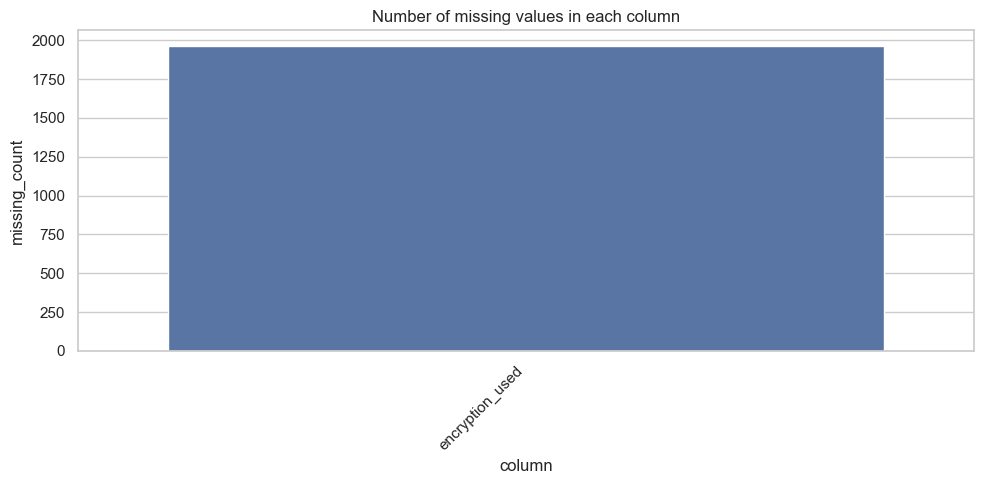

In [31]:
missing_only = missing_summary[missing_summary["missing_count"] > 0].reset_index().rename(columns={"index": "column"})

if not missing_only.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=missing_only, x="column", y="missing_count")
    plt.xticks(rotation=45, ha="right")
    plt.title("Number of missing values in each column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values were found in the dataset.")

## Section 8 - Missing-data visual map

This chart shows where the blanks are located in the dataset.  
Each line represents rows and columns, so we can quickly see whether missing values are random or concentrated.

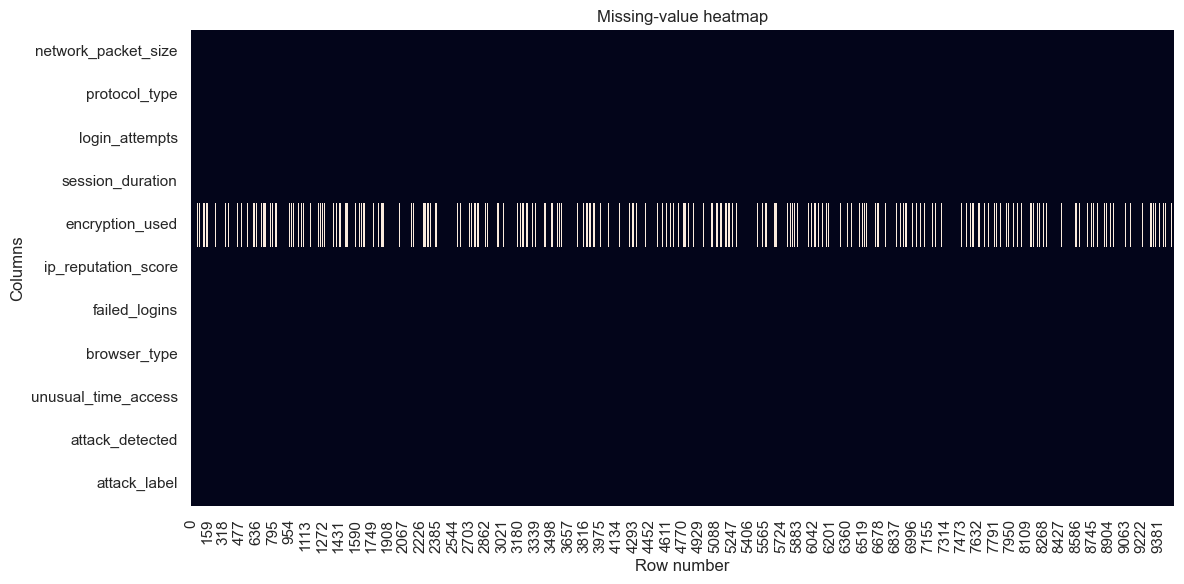

In [32]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna().T, cbar=False)
plt.xlabel("Row number")
plt.ylabel("Columns")
plt.title("Missing-value heatmap")
plt.tight_layout()
plt.show()

## Section 9 - Fill in missing values

In simple terms, this section repairs incomplete data:
- categorical columns are filled using the most frequent category

This is a practical and stable approach for tabular datasets.

In [34]:
# =========================================================
# SECTION: Compare 3 methods for 'encryption_used'
# =========================================================
# This section compares three ways to fill missing values in
# the categorical column 'encryption_used'.

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

col = 'encryption_used'

if col not in df.columns:
    raise KeyError(f"Column '{col}' not found in dataframe.")

if df[col].dropna().empty:
    raise ValueError(f"Column '{col}' has no observed values to evaluate.")

# ---------------------------------------------------------
# Step 1: Create evaluation copy
# ---------------------------------------------------------
# We hide 20% of known values to test which method recovers
# them more accurately.

eval_df = df.copy()
observed_idx = eval_df[eval_df[col].notna()].index

rng = np.random.default_rng(42)
n_hide = max(1, int(len(observed_idx) * 0.2))
hide_idx = rng.choice(observed_idx, size=n_hide, replace=False)

eval_df.loc[hide_idx, col] = np.nan

# ---------------------------------------------------------
# Step 2: Define 3 methods
# ---------------------------------------------------------
methods = {
    "most_frequent": SimpleImputer(strategy="most_frequent"),
    "constant_unknown": SimpleImputer(strategy="constant", fill_value="Unknown"),
    "placeholder_missing": SimpleImputer(strategy="constant", fill_value="Missing")
}

results = []

# ---------------------------------------------------------
# Step 3: Evaluate methods
# ---------------------------------------------------------
for method_name, imputer in methods.items():
    temp_df = eval_df[[col]].copy()
    temp_df[col] = imputer.fit_transform(temp_df[[col]]).ravel()

    true_vals = df.loc[hide_idx, col].astype(str)
    pred_vals = temp_df.loc[hide_idx, col].astype(str)

    acc = accuracy_score(true_vals, pred_vals)

    results.append([method_name, acc])

results_df = pd.DataFrame(results, columns=["method", "accuracy"])
print("Comparison of categorical imputation methods:")
print(results_df)

best_method = results_df.loc[results_df["accuracy"].idxmax(), "method"]
print(f"\nBest method selected: {best_method}")

# ---------------------------------------------------------
# Step 4: Apply best method to original dataframe
# ---------------------------------------------------------
if best_method == "most_frequent":
    df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

elif best_method == "constant_unknown":
    df[col] = df[col].fillna("Unknown")

elif best_method == "placeholder_missing":
    df[col] = df[col].fillna("Missing")

# ---------------------------------------------------------
# Step 5: Check result
# ---------------------------------------------------------
print(f"\nMissing values remaining in '{col}':", df[col].isna().sum())
print("\nValue counts after imputation:")
print(df[col].value_counts(dropna=False))

df.head()

Comparison of categorical imputation methods:
                method  accuracy
0        most_frequent   0.69376
1     constant_unknown   0.00000
2  placeholder_missing   0.00000

Best method selected: most_frequent

Missing values remaining in 'encryption_used': 0

Value counts after imputation:
encryption_used
AES    6672
DES    2865
Name: count, dtype: int64


,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected,attack_label
0,599.0,TCP,4.0,492.983263,DES,0.606818,1.0,Edge,0.0,1.0,Attack
1,472.0,TCP,3.0,1557.996461,DES,0.301569,0.0,Firefox,0.0,0.0,No Attack
2,629.0,TCP,3.0,75.044262,DES,0.739164,2.0,Chrome,0.0,1.0,Attack
3,804.0,UDP,4.0,601.248835,DES,0.123267,0.0,Unknown,0.0,1.0,Attack
4,453.0,TCP,5.0,532.540888,AES,0.054874,1.0,Firefox,0.0,0.0,No Attack


## Section 10 - Outlier detection

Outliers are unusually high or low values.  
We use the IQR method here to flag values that are far away from the normal range.

In [35]:
outlier_summary = []
outlier_idx = {}

for col in numeric_feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_idx[col] = df.index[mask].tolist()

    outlier_summary.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_limit": lower,
        "upper_limit": upper,
        "outlier_count": int(mask.sum())
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by="outlier_count", ascending=False)
display(outlier_df)

,column,q1,q3,iqr,lower_limit,upper_limit,outlier_count
5,unusual_time_access,0.000000,0.000000,0.000000,0.000000,0.000000,1430
2,session_duration,231.953006,1105.380602,873.427596,-1078.188387,2415.521996,418
4,failed_logins,1.000000,2.000000,1.000000,-0.500000,3.500000,323
1,login_attempts,3.000000,5.000000,2.000000,0.000000,8.000000,206
0,network_packet_size,365.000000,635.000000,270.000000,-40.000000,1040.000000,37
3,ip_reputation_score,0.191946,0.453388,0.261441,-0.200216,0.845550,21
6,attack_detected,0.000000,1.000000,1.000000,-1.500000,2.500000,0


## Section 11 - Check whether flagged outliers are strong outliers

Some values are slightly outside the normal range but are not extremely unusual.  
This extra check uses a modified z-score to separate mild cases from stronger outliers.

In [36]:
threshold = 3.5
significance_results = []

for col in numeric_feature_cols:
    values = df[col].astype(float)
    median = values.median()
    mad = (values - median).abs().median()

    mild_or_borderline = []
    for idx in outlier_idx.get(col, []):
        val = values.loc[idx]
        if mad > 0:
            mod_z = 0.6745 * (val - median) / mad
        else:
            std = values.std(ddof=0)
            mod_z = 0 if std == 0 else (val - median) / std

        if abs(mod_z) < threshold:
            mild_or_borderline.append(int(idx))

    significance_results.append({
        "column": col,
        "total_iqr_outliers": len(outlier_idx.get(col, [])),
        "mild_or_borderline_outliers": len(mild_or_borderline),
        "sample_indices": mild_or_borderline[:15]
    })

significance_df = pd.DataFrame(significance_results)
display(significance_df)

,column,total_iqr_outliers,mild_or_borderline_outliers,sample_indices
0,network_packet_size,37,34,"[179, 478, 1615, 1957, 2035, 2305, 2506, 2521, 3241, 3716, 3982, 4047, 4784, 4870, 4997]"
1,login_attempts,206,124,"[11, 26, 60, 118, 119, 133, 154, 155, 266, 317, 663, 677, 690, 1109, 1110]"
2,session_duration,418,65,"[104, 194, 738, 971, 1121, 1176, 1248, 1479, 2229, 2265, 2296, 2571, 2686, 2844, 2847]"
3,ip_reputation_score,21,21,"[52, 329, 1049, 1262, 1610, 1654, 2311, 2487, 2540, 2610, 2706, 3008, 6353, 7604, 7772]"
4,failed_logins,323,323,"[38, 67, 139, 157, 258, 263, 272, 294, 308, 351, 363, 381, 399, 423, 431]"
5,unusual_time_access,1430,1430,"[5, 7, 8, 12, 32, 34, 35, 46, 50, 53, 54, 65, 81, 87, 89]"
6,attack_detected,0,0,[]


## Section 12 - Plot count charts for low-cardinality variables

A count chart shows how many times each category appears.  
To keep the notebook readable, we only plot columns that have a small number of unique values.

In [37]:
count_vars = []
for col in categorical_feature_cols + (["attack_label"] if "attack_label" in df.columns else []):
    if df[col].nunique(dropna=False) <= 12:
        count_vars.append(col)

print("Variables selected for count plots:", count_vars)

Variables selected for count plots: ['protocol_type', 'encryption_used', 'browser_type', 'attack_label', 'attack_label']


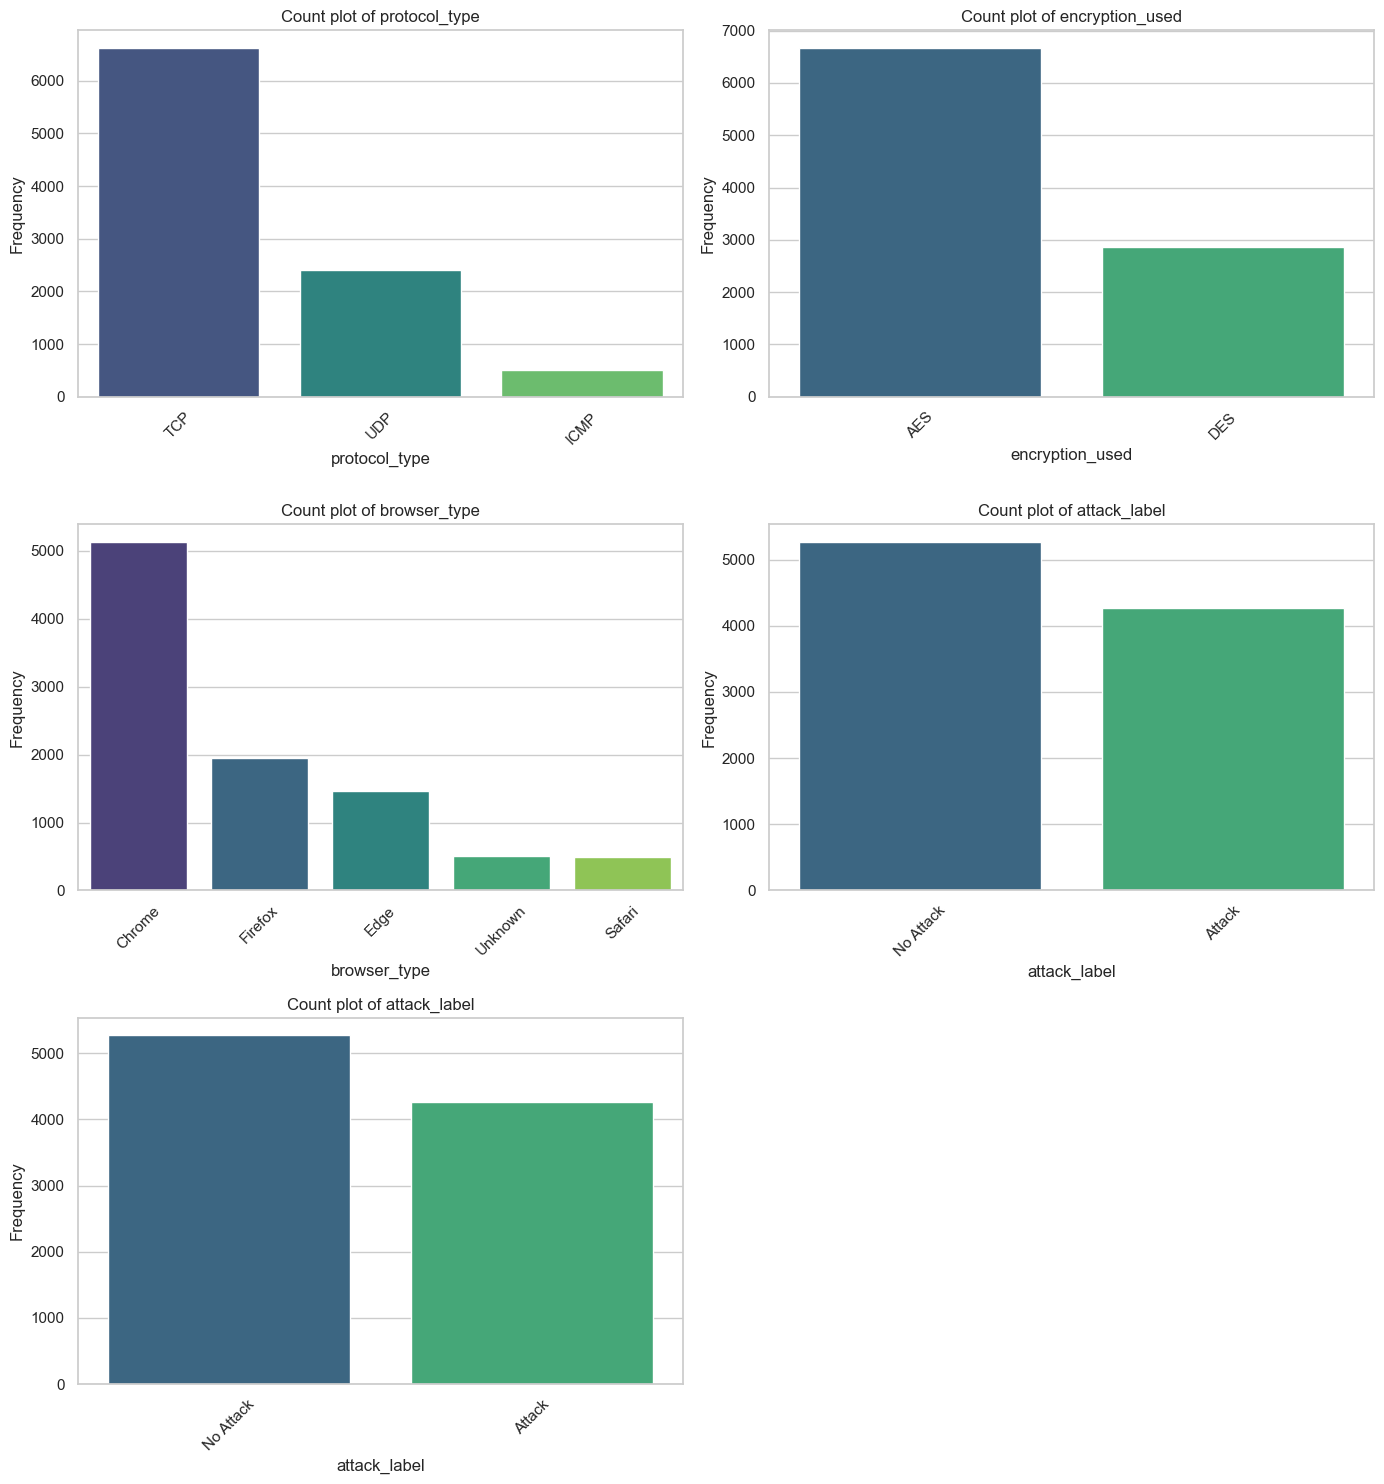

In [45]:
if count_vars:
    n_cols = 2
    n_rows = int(np.ceil(len(count_vars) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, count_vars):
        order = df[col].astype(str).value_counts().index
        sns.countplot(data=df, x=col, order=order, ax=ax, palette='viridis')
        ax.set_title(f"Count plot of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(count_vars):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No suitable low-cardinality variables were found for count plots.")

## Section 13 - Plot distributions for numeric columns

These charts help us understand whether the numeric variables are balanced, skewed, or spread out.

In [39]:
num_matrix = numeric_feature_cols[:min(4, len(numeric_feature_cols))]
print("Numeric columns selected for detailed distribution plots:", num_matrix)

Numeric columns selected for detailed distribution plots: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score']


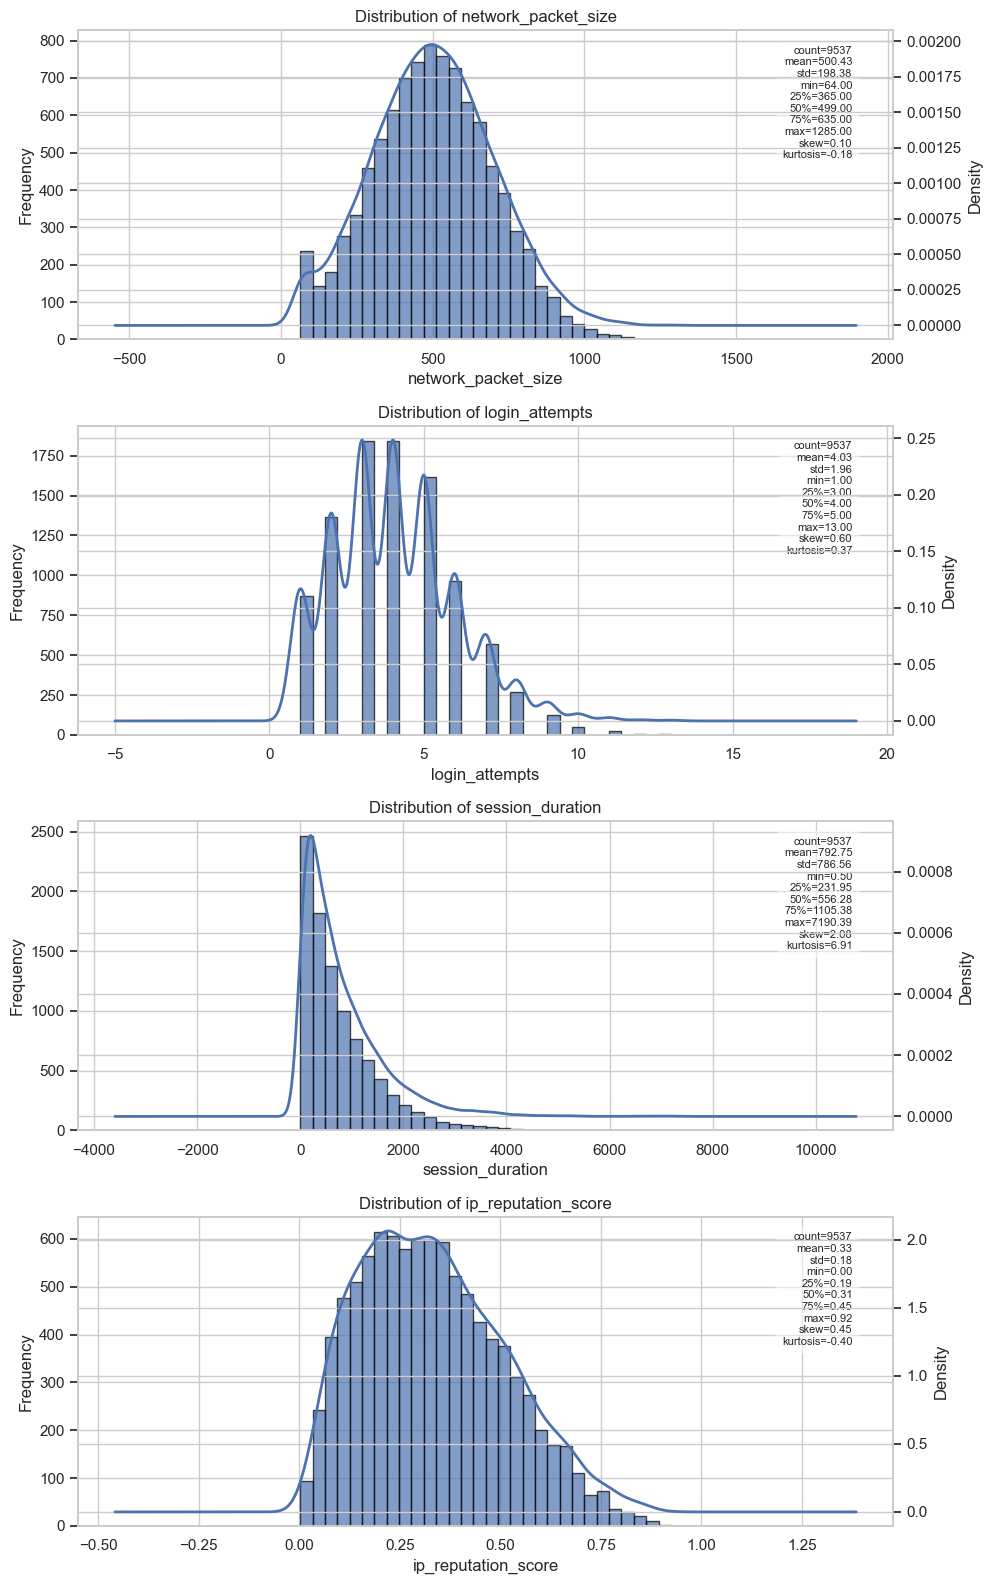

In [52]:
if num_matrix:
    fig, axes = plt.subplots(len(num_matrix), 1, figsize=(10, 4 * len(num_matrix)))
    if len(num_matrix) == 1:
        axes = [axes]

    for ax, col in zip(axes, num_matrix):
        data = df[col].dropna()
        desc = data.describe()
        skewness = data.skew()
        kurtosis = data.kurtosis()

        data.hist(bins=30, ax=ax, edgecolor="black", alpha=0.7)
        ax2 = ax.twinx()
        data.plot(kind="kde", ax=ax2, linewidth=2)

        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax2.set_ylabel("Density")

        summary_text = (
            f"count={int(desc['count'])}\n"
            f"mean={desc['mean']:.2f}\n"
            f"std={desc['std']:.2f}\n"
            f"min={desc['min']:.2f}\n"
            f"25%={desc['25%']:.2f}\n"
            f"50%={desc['50%']:.2f}\n"
            f"75%={desc['75%']:.2f}\n"
            f"max={desc['max']:.2f}\n"
            f"skew={skewness:.2f}\n"
            f"kurtosis={kurtosis:.2f}"
        )
        ax.text(0.95, 0.95, summary_text, transform=ax.transAxes,
                fontsize=8, verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.show()
else:
    print("No numeric feature columns were available for distribution plots.")

## Section 14 - Donut charts for the main categorical variables

These charts show the share of each category in percentage form.  
They are easy to read for non-technical audiences.

In [42]:
cat_plot_cols = [col for col in categorical_feature_cols if df[col].nunique() <= 8][:4]
print("Categorical columns selected for donut charts:", cat_plot_cols)

Categorical columns selected for donut charts: ['protocol_type', 'encryption_used', 'browser_type', 'attack_label']


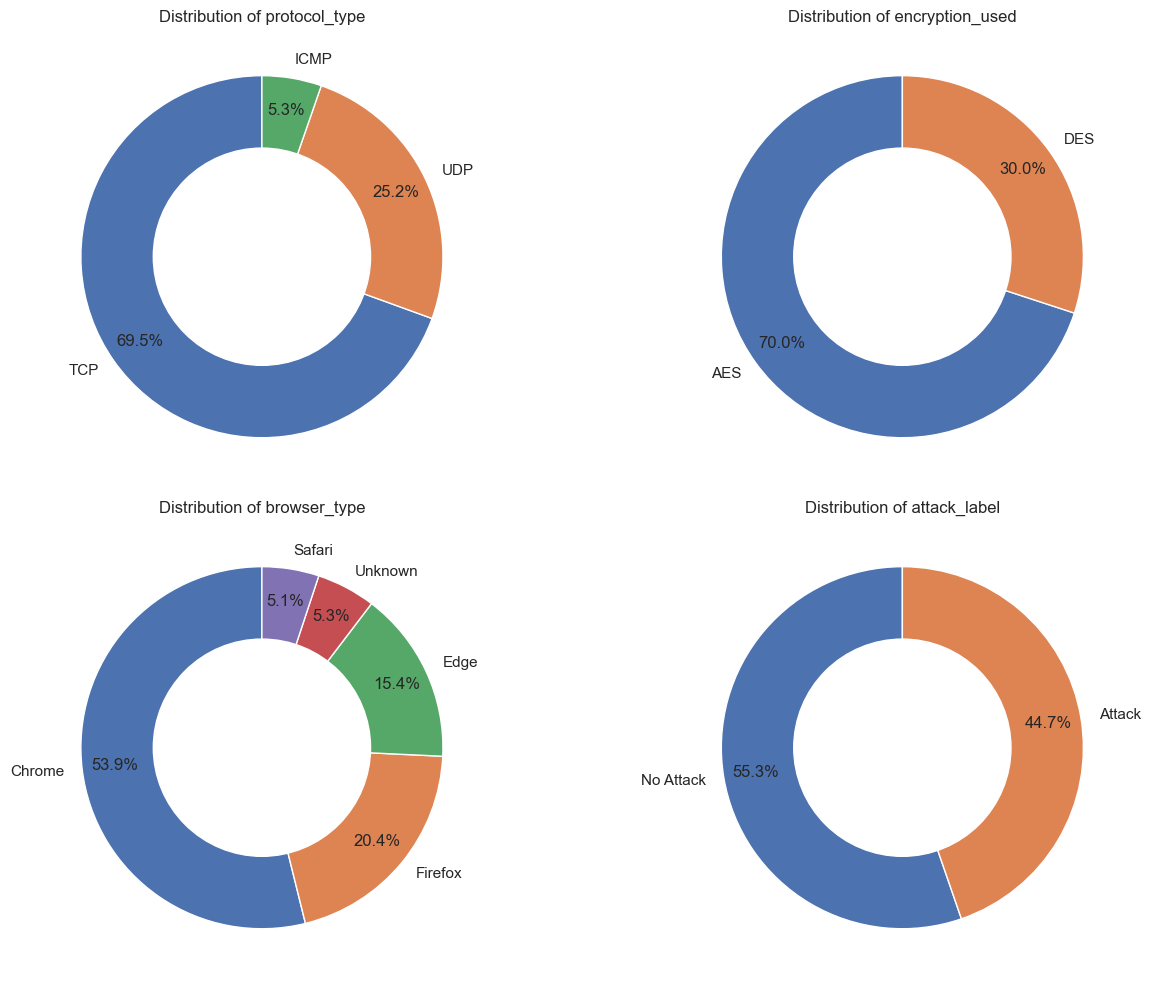

In [43]:
if cat_plot_cols:
    n = len(cat_plot_cols)
    n_cols = 2
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cat_plot_cols):
        counts = df[col].value_counts()
        wedges, texts, autotexts = ax.pie(
            counts.values,
            labels=counts.index,
            autopct="%1.1f%%",
            startangle=90,
            pctdistance=0.82
        )
        centre_circle = plt.Circle((0, 0), 0.60, fc="white")
        ax.add_artist(centre_circle)
        ax.set_title(f"Distribution of {col}")

    for ax in axes[len(cat_plot_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No suitable categorical columns were found for donut charts.")

## Section 15 - Correlation analysis

In this section, we measure relationships between variables.
We use different methods depending on the data type:
1. Numeric vs Numeric        -> Pearson correlation
2. Categorical vs Categorical -> Cramer's V
3. Numeric vs Categorical     -> Correlation Ratio

This gives a more meaningful result than forcing all columns
into one single numeric correlation method.


Numeric columns:
['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected']

Categorical columns:
['protocol_type', 'encryption_used', 'browser_type', 'attack_label']


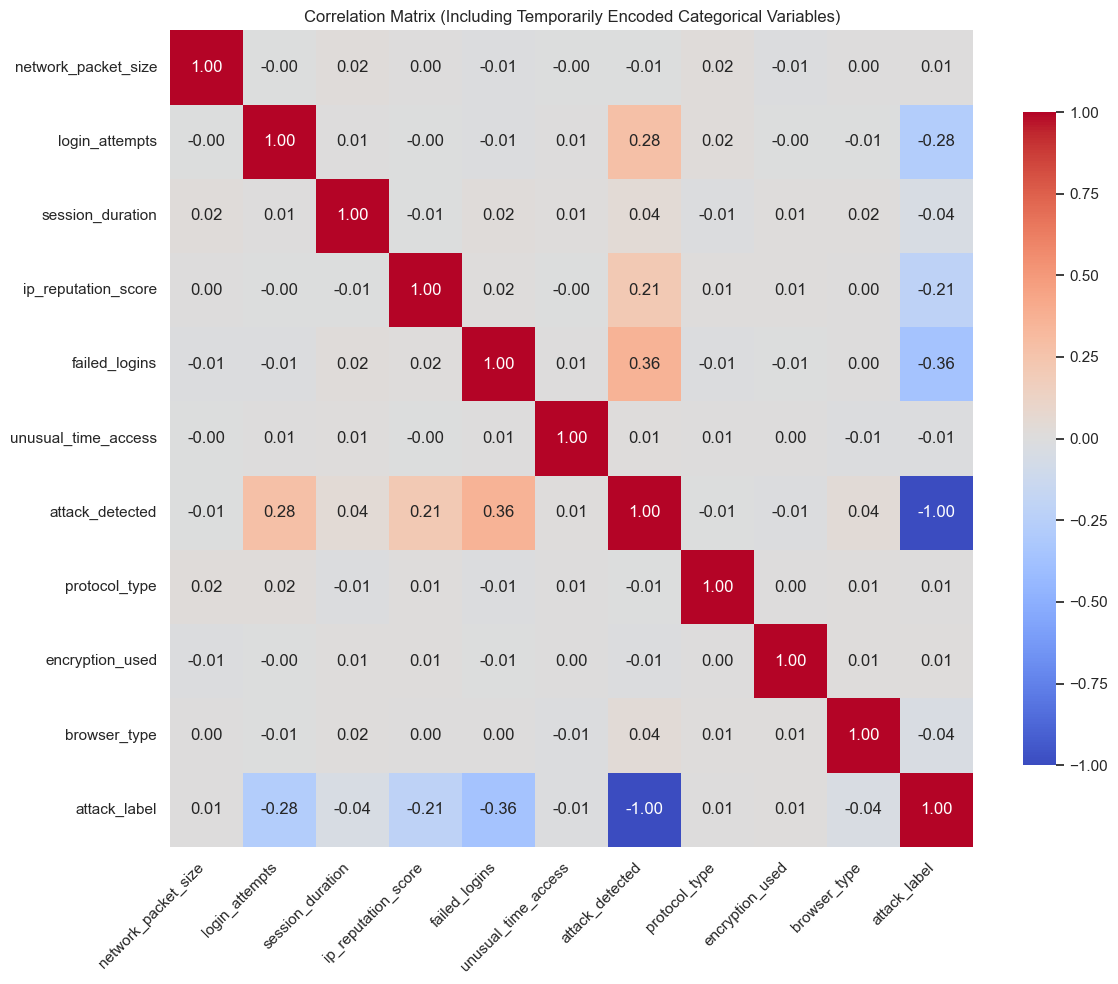

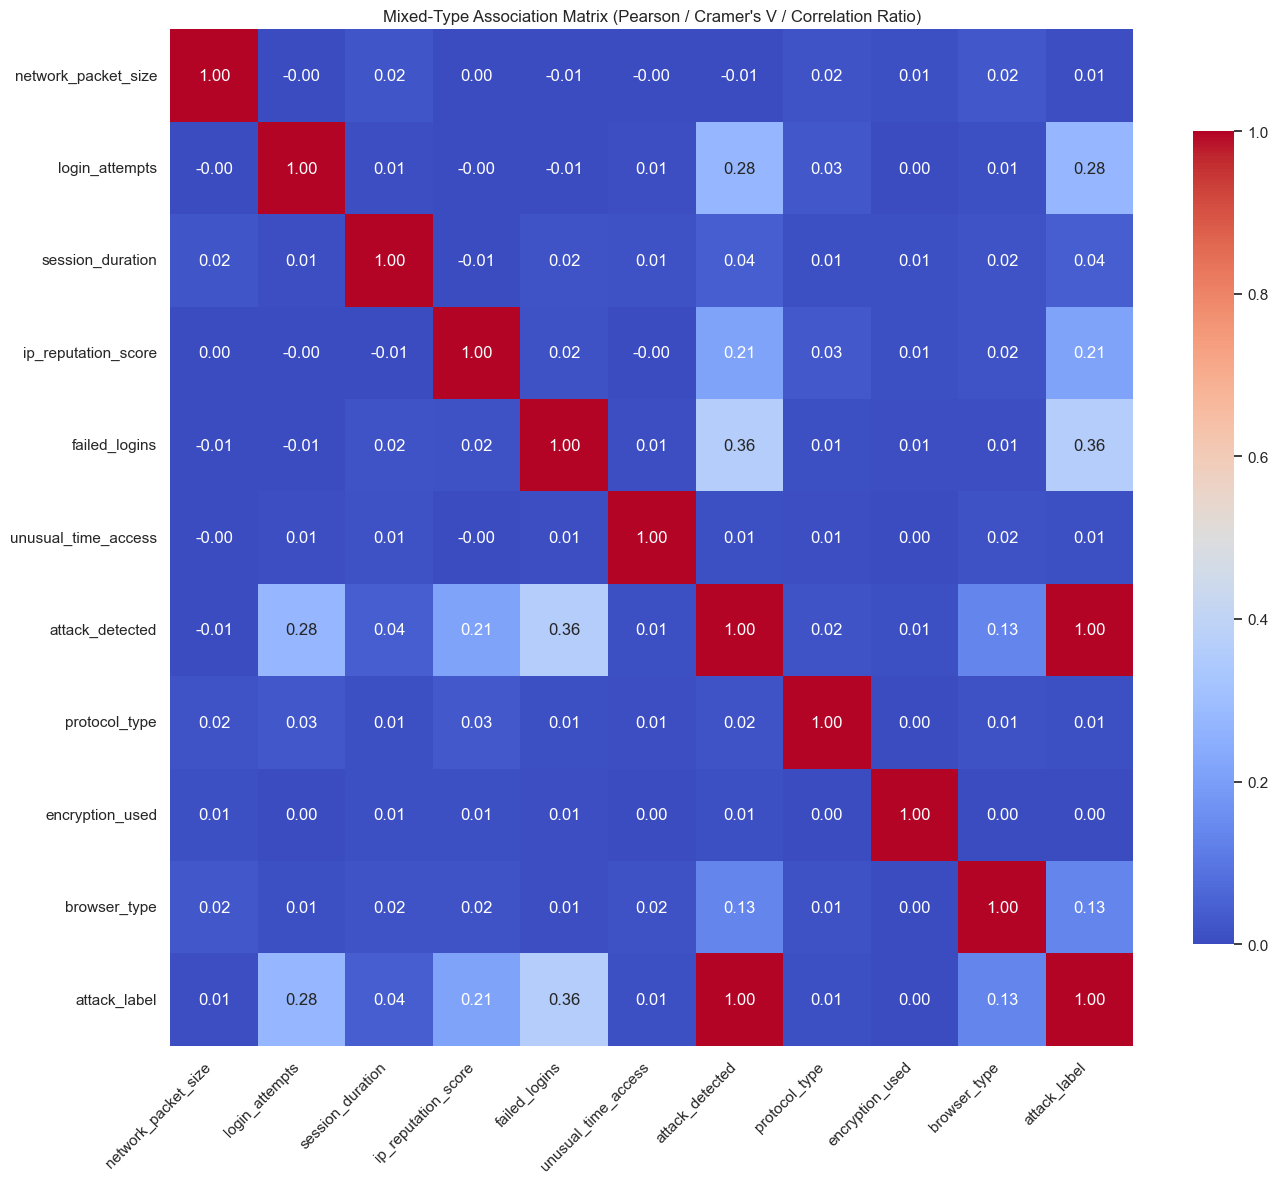

In [54]:
# ============================================================
# SECTION: Correlation and Association Analysis
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# Step 1: Identify numeric and categorical columns
# ------------------------------------------------------------
# Numeric columns contain numbers.
# Categorical columns contain labels/text such as protocol type,
# attack class, encryption type, etc.

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:")
print(num_cols)
print("\nCategorical columns:")
print(categorical_cols)

# ------------------------------------------------------------
# Step 2: Simple encoded correlation heatmap
# ------------------------------------------------------------
# For a quick overview, we temporarily convert categorical
# columns into integer labels and then calculate a standard
# correlation matrix.
#
# Note:
# This is only a rough overview for categorical variables.
# It should not be treated as the final statistical measure.

if num_cols or categorical_cols:
    corr_df = df[num_cols + categorical_cols].copy()

    for c in categorical_cols:
        corr_df[c] = pd.factorize(corr_df[c])[0]

    corr = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        cbar_kws={'shrink': 0.8}
    )
    plt.title('Correlation Matrix (Including Temporarily Encoded Categorical Variables)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Step 3: Define Cramer's V for categorical-categorical pairs
# ------------------------------------------------------------
# Cramer's V measures the strength of association between two
# categorical variables. Its value ranges from 0 to 1:
# 0 = no relationship
# 1 = very strong relationship

def cramers_v(x, y):
    cm = pd.crosstab(x, y)

    if cm.empty:
        return 0.0

    chi2 = chi2_contingency(cm, correction=False)[0]
    n = cm.to_numpy().sum()

    if n == 0:
        return 0.0

    phi2 = chi2 / n
    r, k = cm.shape

    # Bias correction
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)

    denom = min(kcorr - 1, rcorr - 1)

    if denom <= 0:
        return 0.0

    return np.sqrt(phi2corr / denom)

# ------------------------------------------------------------
# Step 4: Define Correlation Ratio for categorical-numeric pairs
# ------------------------------------------------------------
# Correlation Ratio (eta) shows how strongly a categorical
# variable is associated with a numeric variable.
# It ranges from 0 to 1:
# 0 = no relationship
# 1 = strong relationship

def correlation_ratio(categories, measurements):
    categories = pd.Series(categories)
    measurements = pd.Series(measurements)

    mask = categories.notna() & measurements.notna()
    if mask.sum() == 0:
        return 0.0

    categories = categories[mask]
    measurements = measurements[mask].astype(float)

    codes, _ = pd.factorize(categories)
    overall_mean = measurements.mean()

    ss_between = 0.0
    for level in np.unique(codes):
        values = measurements[codes == level]
        if len(values) == 0:
            continue
        ss_between += len(values) * (values.mean() - overall_mean) ** 2

    ss_total = ((measurements - overall_mean) ** 2).sum()

    if ss_total == 0:
        return 0.0

    return np.sqrt(ss_between / ss_total)

# ------------------------------------------------------------
# Step 5: Build mixed-type association matrix
# ------------------------------------------------------------
# This is the main analysis table.
# It chooses the correct measure based on variable types:
#
# - Numeric + Numeric       -> Pearson correlation
# - Categorical + Categorical -> Cramer's V
# - Numeric + Categorical     -> Correlation Ratio

all_cols = num_cols + categorical_cols

mixed_corr = pd.DataFrame(
    np.zeros((len(all_cols), len(all_cols))),
    index=all_cols,
    columns=all_cols
)

for i, col1 in enumerate(all_cols):
    for j, col2 in enumerate(all_cols):
        if i == j:
            mixed_corr.loc[col1, col2] = 1.0
            continue

        s1 = df[col1]
        s2 = df[col2]

        mask = s1.notna() & s2.notna()

        if mask.sum() == 0:
            mixed_corr.loc[col1, col2] = 0.0
            continue

        s1_valid = s1[mask]
        s2_valid = s2[mask]

        # Numeric vs Numeric
        if col1 in num_cols and col2 in num_cols:
            val = s1_valid.astype(float).corr(s2_valid.astype(float))
            mixed_corr.loc[col1, col2] = 0.0 if pd.isna(val) else val

        # Categorical vs Categorical
        elif col1 in categorical_cols and col2 in categorical_cols:
            mixed_corr.loc[col1, col2] = cramers_v(s1_valid, s2_valid)

        # Mixed pair: one numeric and one categorical
        else:
            if col1 in categorical_cols:
                mixed_corr.loc[col1, col2] = correlation_ratio(s1_valid, s2_valid)
            else:
                mixed_corr.loc[col1, col2] = correlation_ratio(s2_valid, s1_valid)

# ------------------------------------------------------------
# Step 6: Plot the mixed-type association matrix
# ------------------------------------------------------------
# This heatmap is more meaningful than ordinary correlation
# when the dataset contains both numeric and categorical data.

plt.figure(figsize=(14, 12))
sns.heatmap(
    mixed_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,          # better for mixed measures that mostly range 0 to 1
    vmax=1,
    cbar_kws={'shrink': 0.8}
)
plt.title("Mixed-Type Association Matrix (Pearson / Cramer's V / Correlation Ratio)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 16 - Prepare data for machine learning

Now we split the data into input features and the target column.  
Then we divide the dataset into training data and testing data so that model performance is measured fairly.

In [55]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET_COL, "attack_label"], errors="ignore")
y = df[TARGET_COL]

if not pd.api.types.is_numeric_dtype(y):
    y = pd.factorize(y)[0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (6675, 9)
Testing set: (2862, 9)


## Section 17 - Build preprocessing pipeline

Machine learning models need clean numeric input.  
So here we automatically:
- scale numeric columns
- one-hot encode categorical columns

This ensures all models receive data in the correct format.

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
model_categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), model_numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), model_categorical_cols),
    ],
    remainder="drop"
)

print("Numeric columns used in modelling:", model_numeric_cols)
print("Categorical columns used in modelling:", model_categorical_cols)

Numeric columns used in modelling: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']
Categorical columns used in modelling: ['protocol_type', 'encryption_used', 'browser_type']


## Section 18 - Train classical machine learning models

This section compares several common machine learning models.  
The goal is to see which model performs best for predicting whether an intrusion is detected.

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

results = []
roc_curves = {}
pr_curves = {}
best_estimators = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    # =========================
    # Train model
    # =========================
    pipeline.fit(X_train, y_train)
    best_estimators[model_name] = pipeline

    y_pred = pipeline.predict(X_test)

    # =========================
    # Get prediction scores
    # =========================
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline.named_steps["model"], "decision_function"):
        y_score = pipeline.decision_function(X_test)
    else:
        y_score = None

    # =========================
    # Evaluation metrics
    # =========================
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        pr_auc = average_precision_score(y_test, y_score)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_score)

        roc_curves[model_name] = (fpr, tpr)
        pr_curves[model_name] = (recall_curve, precision_curve)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # =========================
    # Extract model parameters
    # =========================
    params = pipeline.named_steps["model"].get_params()

    # Keep only important parameters (to avoid huge output)
    key_params = {k: v for k, v in params.items() if k in [
        "C", "max_depth", "n_estimators", "kernel",
        "n_neighbors", "max_features"
    ]}

    # =========================
    # Store results
    # =========================
    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "BestParams": str(key_params)   # 👈 added here
    })

# =========================
# Final results table
# =========================
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 120)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP,BestParams
0,Random Forest,0.881901,0.981595,0.750000,0.850310,0.872800,0.904092,1564,18,320,960,"{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}"
1,SVM,0.871768,0.965341,0.739844,0.837682,0.873102,0.904011,1548,34,333,947,"{'C': 1.0, 'kernel': 'rbf'}"
2,Decision Tree,0.817959,0.802873,0.785937,0.794315,0.814903,0.726745,1335,247,274,1006,"{'max_depth': None, 'max_features': None}"
3,KNN,0.798742,0.865145,0.651563,0.743316,0.831062,0.821756,1452,130,446,834,{'n_neighbors': 5}
4,Logistic Regression,0.728861,0.714651,0.655469,0.683782,0.788946,0.795014,1247,335,441,839,{'C': 1.0}


## Section 19 - Plot ROC curves

An ROC curve shows how well each model separates normal records from attack records.  
A curve closer to the top-left corner is usually better.

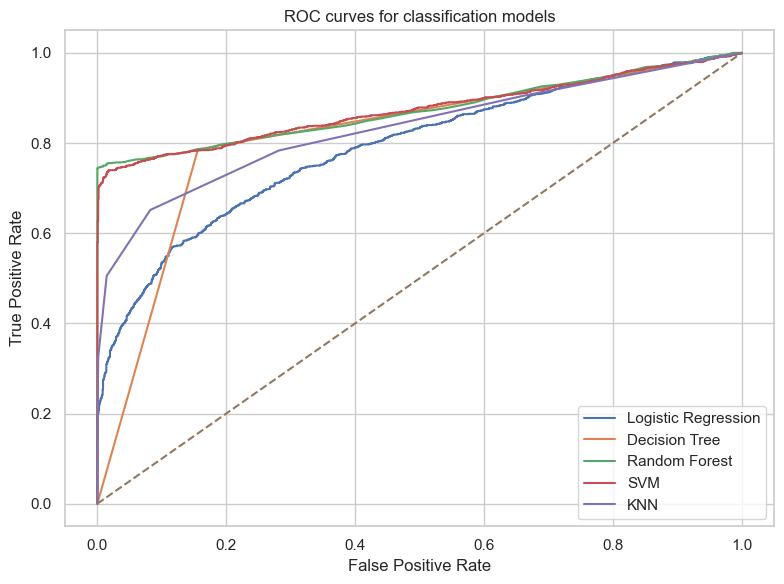

In [68]:
if roc_curves:
    plt.figure(figsize=(8, 6))
    for name, (fpr, tpr) in roc_curves.items():
        plt.plot(fpr, tpr, label=name)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves for classification models")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("ROC curves could not be plotted because probability scores were unavailable.")

## Section 20 - Plot Precision-Recall curves

This chart is especially helpful when the target classes are imbalanced.  
It shows how well the model finds attacks while controlling false alarms.

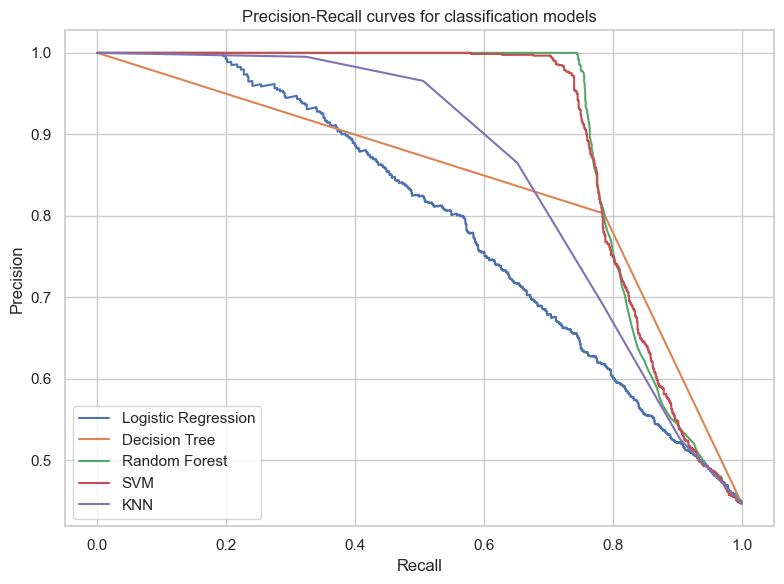

In [69]:
if pr_curves:
    plt.figure(figsize=(8, 6))
    for name, (recall_curve, precision_curve) in pr_curves.items():
        plt.plot(recall_curve, precision_curve, label=name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curves for classification models")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Precision-Recall curves could not be plotted because probability scores were unavailable.")

## Section 21 - Show confusion matrix for the best model

A confusion matrix explains the prediction results in plain counts:
- true negatives
- false positives
- false negatives
- true positives

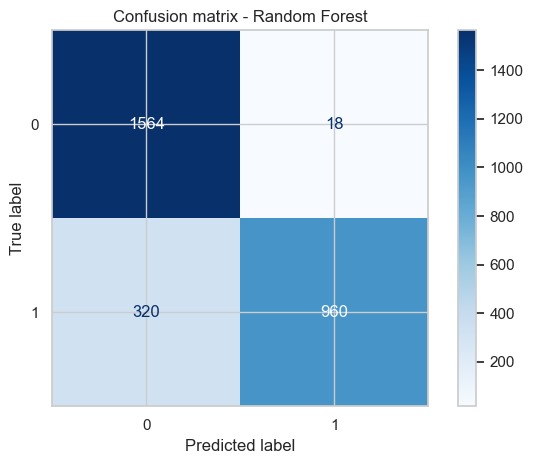

In [70]:
best_model_name = results_df.loc[0, "Model"]
best_model = best_estimators[best_model_name]

best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## Section 22 - Explainability using SHAP

This final section helps explain which features influenced the best tree-based model.  
It runs only when the best model is a tree-based model and the `shap` package is installed.

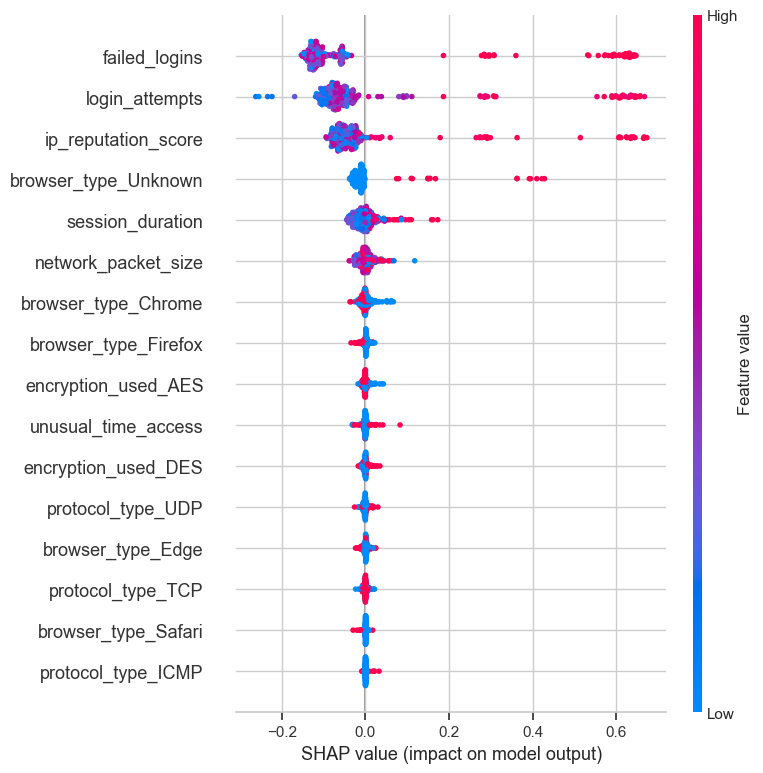

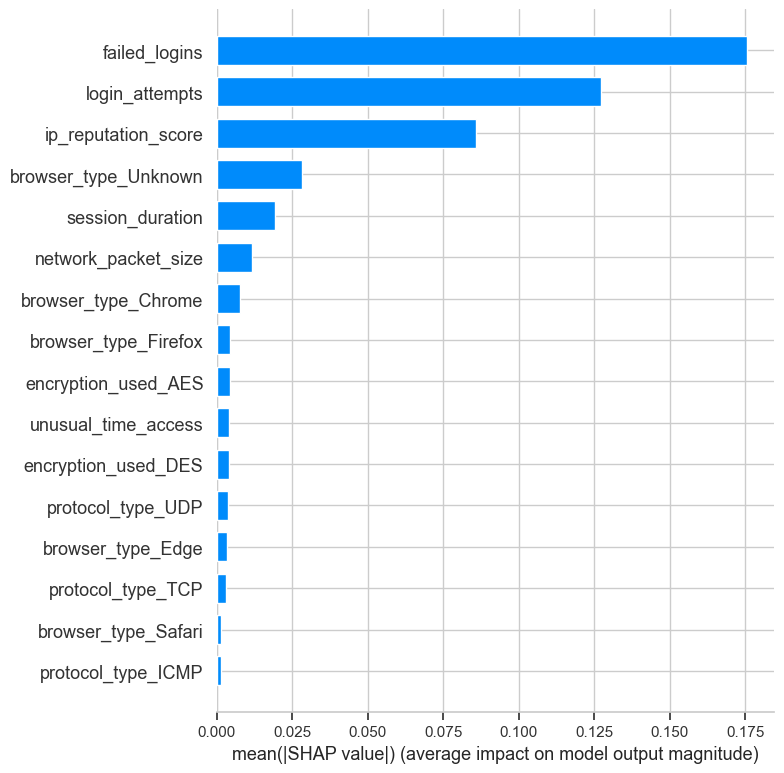

In [71]:
try:
    import shap

    if best_model_name in ["Decision Tree", "Random Forest"]:
        prep = best_model.named_steps["prep"]
        model = best_model.named_steps["model"]

        X_test_transformed = prep.transform(X_test)
        if hasattr(X_test_transformed, "toarray"):
            X_test_transformed = X_test_transformed.toarray()

        feature_names = model_numeric_cols.copy()
        if model_categorical_cols:
            ohe = prep.named_transformers_["cat"]
            feature_names += list(ohe.get_feature_names_out(model_categorical_cols))

        sample_size = min(300, X_test_transformed.shape[0])
        sample_idx = np.random.default_rng(42).choice(X_test_transformed.shape[0], size=sample_size, replace=False)
        X_sample = X_test_transformed[sample_idx]

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        if isinstance(shap_values, list):
            shap_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_to_plot = shap_values[:, :, 1]
        else:
            shap_to_plot = shap_values

        shap.summary_plot(shap_to_plot, X_sample, feature_names=feature_names)
        shap.summary_plot(shap_to_plot, X_sample, feature_names=feature_names, plot_type="bar")
    else:
        print("SHAP explanation was skipped because the best model is not tree-based.")
except ImportError:
    print("SHAP is not installed. Install it with: pip install shap")
except Exception as e:
    print(f"SHAP section could not be completed: {e}")